In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', ".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from database import FY3DImageArea, FY3DImage
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from utils.some_utils import change_contrast
import seaborn as sns
import optimization
import pandas as pd

In [2]:
%matplotlib widget

In [10]:
# Оригинальное изображение
img = FY3DImage.get(id=119)
ch_img = img.get_vis_channel(8)
plt.imshow(ch_img, cmap="gray")

In [4]:
# Изменение контраста
contrasted_img = change_contrast(ch_img, 1000, 1300)
plt.imshow(contrasted_img, cmap="gray")

In [5]:
# Применение медианы
median_img = median_filter(ch_img, size=5)
contrasted_median = change_contrast(median_img, 1000, 1300)
plt.imshow(contrasted_median, cmap="gray")

# Применяем к областям

27369.83692825895
27369.836928249322
27369.836928249246
27369.836928249246
27374.204543212276
27369.83692825822
27369.83692825822
27369.83692825578
27369.83692825578
27373.912473063017
27369.83692825825
27369.83692825825
27369.83692825513
27369.83692825513
27373.885149979742
27369.83692825895
27369.83692825895
27369.836928255587
27369.836928255587
27374.09354873997
27369.8369282567
27369.8369282567
27369.836928254957
27369.836928254957
27374.113681357554
27369.836928255278
27369.836928255278
27369.83692825331
27369.83692825331
27374.126600187912
27369.836928258934
27369.836928258934
27369.836928255514
27369.836928255514
27374.07662774488
27369.83692825895
27369.83692825895
27369.836928255496
27369.836928255496
27374.19050797698
27369.836928258945
27369.836928258945
27369.83692825547
27369.83692825547
27374.14239648386
27369.836928258956
27369.836928258956
27369.83692825563
27369.83692825563
27373.13434965886
[-0.027882175582914392, 0.05544824478585053, 0.00010261182912429217, 0.0547428

'\n\n\n'

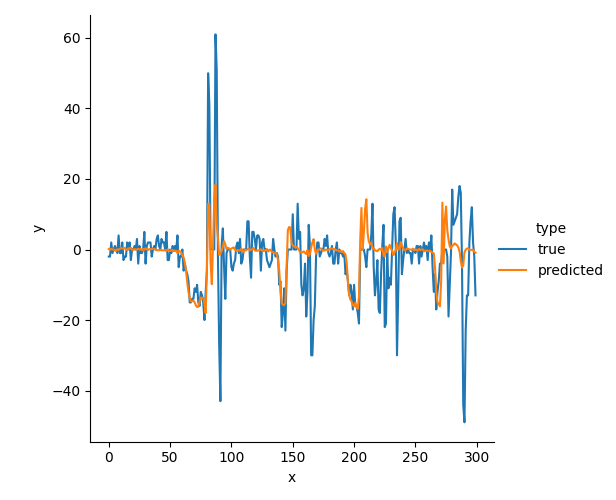

In [9]:
#area_ids = [8917, 8918, 8919, 8920] + [8921, 8922, 8923, 8924, 8925, 8926, 8927, 8928, 8929]
area_ids = [8917]
area_ids = [8917, 8918, 8919, 8920]
area, median_values = optimization.connect_areas(area_ids, ch_img)

'''
for sensor in range(0, 10):
    #print("Sensor", sensor)
    coeffs = optimization.optimize(area, median_values, sensor)
    print(f"coeffs[{sensor}, 0:10] =", list(coeffs))
    #print()
'''



sensor = 2
coeffs = optimization.optimize(area, median_values, sensor, n_iters=50)
print(list(coeffs))

true_values = area[sensor] - median_values[sensor]
predicted_values = optimization.get_predicted_values(coeffs, area, sensor)

N = len(true_values)
df = pd.DataFrame({
    "x": list(range(N)) * 2,
    "y": list(true_values) + list(predicted_values),
    "type": ["true"] * N + ["predicted"] * N
})
sns.relplot(data=df, x="x", y="y", hue="type", kind="line")
"""


"""